# Dataset Statistics 

In [1]:
import os
from argparse import ArgumentParser
import torch
from torch.utils.data import DataLoader
import lightning as L
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from dataset import MouseTracks
from metrics import paired_euclidean_distances

## Time statistics

In [2]:
data = pd.read_csv("./glob3DBodyParts.csv")
time = data.time.unique()
timestep = round(time[1] - time[0], 3)
print("Timestep: {} s".format(timestep))

Timestep: 0.033 s


## Space dimensions

In [3]:
data = pd.read_csv("./glob3DBodyParts.csv")
positions_d = data.iloc[:, 5:]

# Translate to positive coordinates
positions_d -= positions_d.min()

x_max, y_max, z_max = positions_d.max()
x_max, y_max, z_max = round(x_max, 2), round(y_max, 2), round(z_max, 2)

In [4]:
print("Dimensions: \nx: {} mm   y: {} mm   z: {} mm".format(x_max, y_max, z_max))

Dimensions: 
x: 587.49 mm   y: 581.64 mm   z: 27.0 mm


## Mouse dimensions

In [5]:
dataset = MouseTracks("./glob3DBodyParts.csv", seq_length=100, norm=False)
generator = torch.Generator().manual_seed(42)

batch_size = 128
data = DataLoader(dataset, batch_size=batch_size,)

In [6]:
length_mean, height_mean = [], []
length_std, height_std = [], []

for x, y in data:

    length = paired_euclidean_distances(y[..., 0, :2], y[..., 7, :2]) # nose - tail base (only x and y)
    height = paired_euclidean_distances(y[..., 1, 2:], y[..., 3, 2:]) # left ear - left front paw (only z)

    length_mean.append(length.mean())
    height_mean.append(height.mean())
    length_std.append(length.std(dim=1).mean())
    height_std.append(height.std(dim=1).mean())

In [7]:
length_mean = np.round(np.array(length_mean).mean().item(), 2)
height_mean = np.round(np.array(height_mean).mean().item(), 2)
length_std = np.round(np.array(length_std).mean().item(), 2)
height_std = np.round(np.array(height_std).mean().item(), 2)

In [8]:
print("Length: {} +- {} mm \nHeight: {} +- {} mm".format(length_mean, length_std, height_mean, height_std))

Length: 65.8 +- 0.18 mm 
Height: 27.0 +- 0.0 mm


## Skeleton

In [9]:
dataset = MouseTracks("./glob3DBodyParts.csv", seq_length=100, norm=False)
generator = torch.Generator().manual_seed(42)

batch_size = 128
data = DataLoader(dataset, batch_size=batch_size,)

In [10]:
s = ["01", "02", "81", "82", "83", "84", "89", "95", "96", "97"]
mean, std = {k: [] for k in s}, {k: [] for k in s}

for x, y in data:    
    for k in s:
        d = paired_euclidean_distances(y[..., int(k[0]), :], y[..., int(k[1]), :]) 
        mean[k].append(d.mean()), std[k].append(d.std())

In [11]:
# Average over the dataloader
mean, std = {k: np.array(v).mean() for k, v in mean.items()}, {k: np.array(v).mean() for k, v in std.items()}

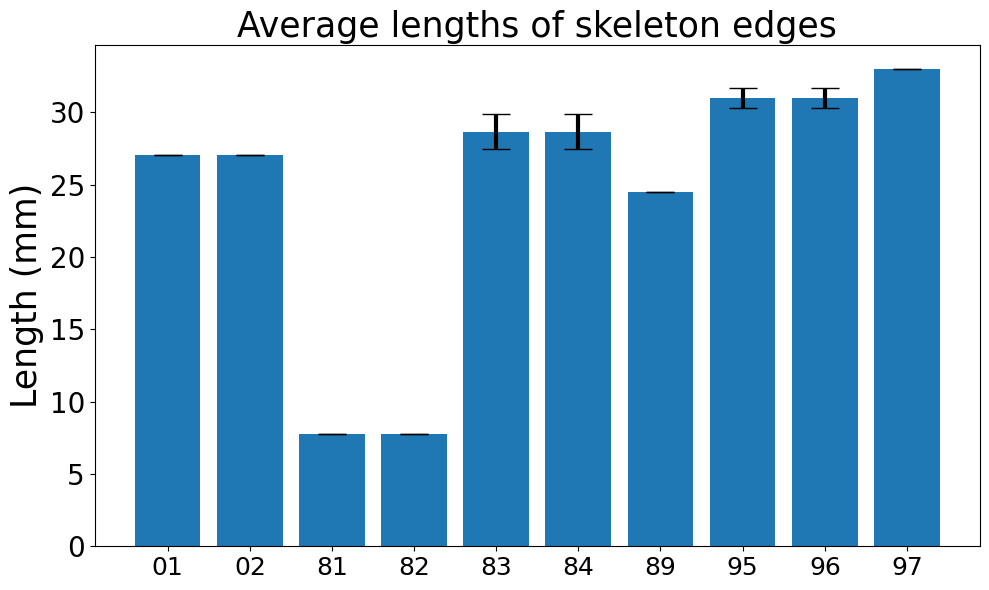

In [12]:
mean_array, std_array = np.array(list(mean.values())), np.array(list(std.values()))

# Plot a bar graph with standard deviations as error bars
_ = plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(s)), mean_array, yerr=std_array, capsize=10, error_kw={"elinewidth": 3})
plt.xticks(np.arange(len(s)), labels=s, fontsize=18)
plt.yticks(fontsize=20)
plt.ylabel("Length (mm)", size=25)
plt.title("Average lengths of skeleton edges", size=25)
fig_name = None
if fig_name != None:
    # Save as SVG file
    plt.savefig(r"C:\Users\mathi\Documents\DD\Cours\MT\writing\images\{}.svg".format(fig_name))
plt.tight_layout()